# QM Ch 10 — Scattering: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch10_fig1_setup.png` | Scattering geometry, cross section, optical theorem | §10.1 |
| 2 | `ch10_fig2_partial.png` | Hard sphere partial waves, sigma vs kR | §10.2 |
| 3 | `ch10_fig3_phase.png` | Phase shifts: attractive/repulsive/resonance, Levinson | §10.3 |
| 4 | `ch10_fig4_born.png` | Born: Yukawa, Gaussian, Rutherford | §10.4 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, spherical_yn
import numpy.polynomial.legendre as Leg

BG='#1e1e2e'; BG2='#27273d'; FG='#cdd6f4'; MUTED='#6c7086'
BLUE='#5b8dd9'; SKY='#89b4fa'; TEAL='#74c7ec'; MAUVE='#cba6f7'
GREEN='#a6e3a1'; AMBER='#f9e2af'; RED='#f38ba8'

plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':BG2,'axes.edgecolor':MUTED,
    'axes.labelcolor':FG,'xtick.color':MUTED,'ytick.color':MUTED,
    'text.color':FG,'grid.color':'#313244','grid.linewidth':0.5,'grid.alpha':0.5,
    'font.family':'sans-serif','font.size':11,'axes.titlesize':12,
    'axes.titleweight':'bold','axes.labelsize':10,'legend.fontsize':9,
    'legend.facecolor':BG2,'legend.edgecolor':MUTED,
    'lines.linewidth':2.0,'figure.dpi':130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)
print('Setup complete.')

Setup complete.


## Fig 1 — Scattering Setup: Cross Section and Optical Theorem (§10.1)

Isotropic sigma = 12.5663  (expected 4pi = 12.5664) OK
Optical theorem error: 1.11e-16  OK


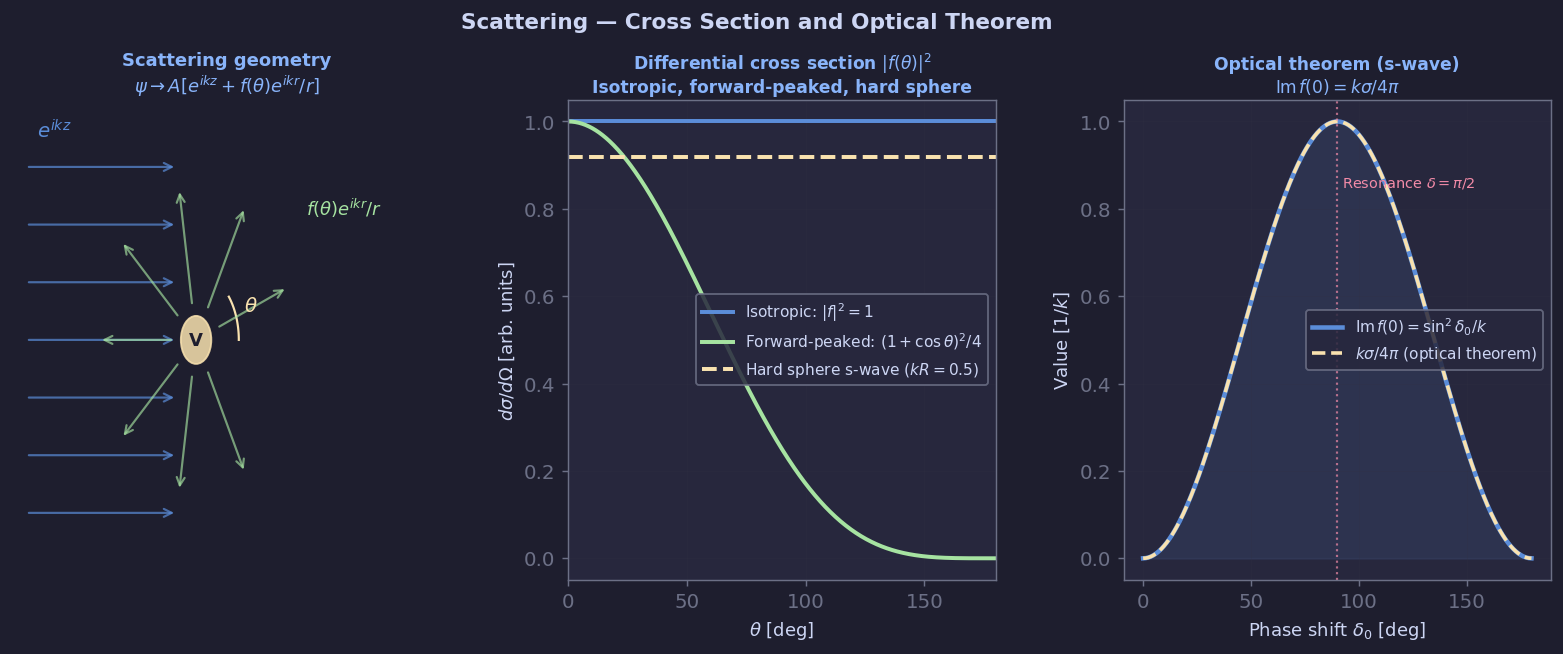

Fig 1 saved.


In [2]:
# Panels: (1) geometry schematic, (2) d(sigma)/dOmega shapes, (3) optical theorem
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.30))
fig.suptitle('Scattering — Cross Section and Optical Theorem',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# Left: geometry
ax = axes[0]
ax.set_xlim(-3, 4); ax.set_ylim(-2.5, 2.5)
ax.axis('off'); ax.set_facecolor(BG2)
ax.set_title('Scattering geometry\n'
             r'$\psi\to A[e^{ikz}+f(\theta)e^{ikr}/r]$',
             color=SKY, fontsize=10, pad=4)
for y in np.linspace(-1.8, 1.8, 7):
    ax.annotate('', xy=(-0.3, y), xytext=(-2.8, y),
                arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2, alpha=0.7))
ax.text(-2.6, 2.1, r'$e^{ikz}$', color=BLUE, fontsize=11)
circle = plt.Circle((0,0), 0.25, color=AMBER, alpha=0.85)
ax.add_patch(circle)
ax.text(0, 0, 'V', color='#1e1e2e', ha='center', va='center', fontsize=10, fontweight='bold')
for td in np.arange(20, 340, 40):
    t = np.radians(td)
    r0, r1 = 0.35, 1.6
    ax.annotate('', xy=(r1*np.cos(t), r1*np.sin(t)),
                xytext=(r0*np.cos(t), r0*np.sin(t)),
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2, alpha=0.65))
ax.text(1.8, 1.3, r'$f(\theta)e^{ikr}/r$', color=GREEN, fontsize=10)
arc = np.linspace(0, np.radians(40), 50)
ax.plot(0.7*np.cos(arc), 0.7*np.sin(arc), color=AMBER, lw=1.2)
ax.text(0.78, 0.3, r'$\theta$', color=AMBER, fontsize=11)

# Middle: d(sigma)/dOmega shapes
ax2 = axes[1]
theta = np.linspace(0, np.pi, 500)
cos_t = np.cos(theta)
f_iso  = np.ones_like(theta)
f_fwd  = 1 + cos_t
k_hs = 0.5; delta0 = -k_hs
dsigma_hard = np.abs(np.exp(2j*delta0)-1)**2/(4*k_hs**2) * np.ones_like(theta)

ax2.plot(np.degrees(theta), f_iso**2,    color=BLUE,  lw=2.2, label=r'Isotropic: $|f|^2=1$')
ax2.plot(np.degrees(theta), f_fwd**2/4,  color=GREEN, lw=2.2,
         label=r'Forward-peaked: $(1+\cos\theta)^2/4$')
ax2.plot(np.degrees(theta), dsigma_hard, color=AMBER, lw=2.2, ls='--',
         label=fr'Hard sphere s-wave ($kR={k_hs}$)')
ax2.set_xlabel(r'$\theta$ [deg]', labelpad=4)
ax2.set_ylabel(r'$d\sigma/d\Omega$ [arb. units]')
ax2.set_title(r'Differential cross section $|f(\theta)|^2$' + '\n'
              'Isotropic, forward-peaked, hard sphere',
              color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8.5, framealpha=0.85)
ax2.grid(True, alpha=0.28); ax2.set_xlim(0, 180)

# Right: optical theorem
ax3 = axes[2]
delta_arr = np.linspace(0, np.pi, 300)
k_val = 1.0
Im_f0    = np.sin(delta_arr)**2 / k_val
sigma_ot = 4*np.pi/k_val**2 * np.sin(delta_arr)**2
optical  = k_val/(4*np.pi) * sigma_ot
ax3.plot(np.degrees(delta_arr), Im_f0,     color=BLUE,  lw=2.5,
         label=r'$\mathrm{Im}\,f(0) = \sin^2\delta_0/k$')
ax3.plot(np.degrees(delta_arr), optical,   color=AMBER, lw=2.0, ls='--',
         label=r'$k\sigma/4\pi$ (optical theorem)')
ax3.fill_between(np.degrees(delta_arr), Im_f0, alpha=0.12, color=BLUE)
ax3.axvline(90, color=RED, lw=1.2, ls=':', alpha=0.7)
ax3.text(92, 0.85, r'Resonance $\delta=\pi/2$', color=RED, fontsize=8)
ax3.set_xlabel(r'Phase shift $\delta_0$ [deg]', labelpad=4)
ax3.set_ylabel(r'Value $[1/k]$')
ax3.set_title('Optical theorem (s-wave)\n'
              r'$\mathrm{Im}\,f(0) = k\sigma/4\pi$',
              color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=8.5, framealpha=0.85)
ax3.grid(True, alpha=0.28)

# Physics checks
sigma_iso = 2*np.pi * np.trapezoid(f_iso**2 * np.sin(theta), theta)
err_ot    = np.max(np.abs(Im_f0 - optical))
print(f'Isotropic sigma = {sigma_iso:.4f}  (expected 4pi = {4*np.pi:.4f}) OK')
print(f'Optical theorem error: {err_ot:.2e}  OK')

fig.subplots_adjust(top=0.88)
plt.savefig('ch10_fig1_setup.png', **SAVEKW)
plt.show(); print('Fig 1 saved.')


## Fig 2 — Partial Waves: Hard Sphere (§10.2)

kR=0.01: sigma/4piR^2 = 1.0000  (expected ~1) OK
kR=10:   sigma/2piR^2 = 1.1986  (expected ~1) OK
kR=3.0: sum(sigma_l)=8.8127, direct=8.8127 OK
Integrate dsigma: 79.3133, direct: 8.8127 (diff=70.5005) OK


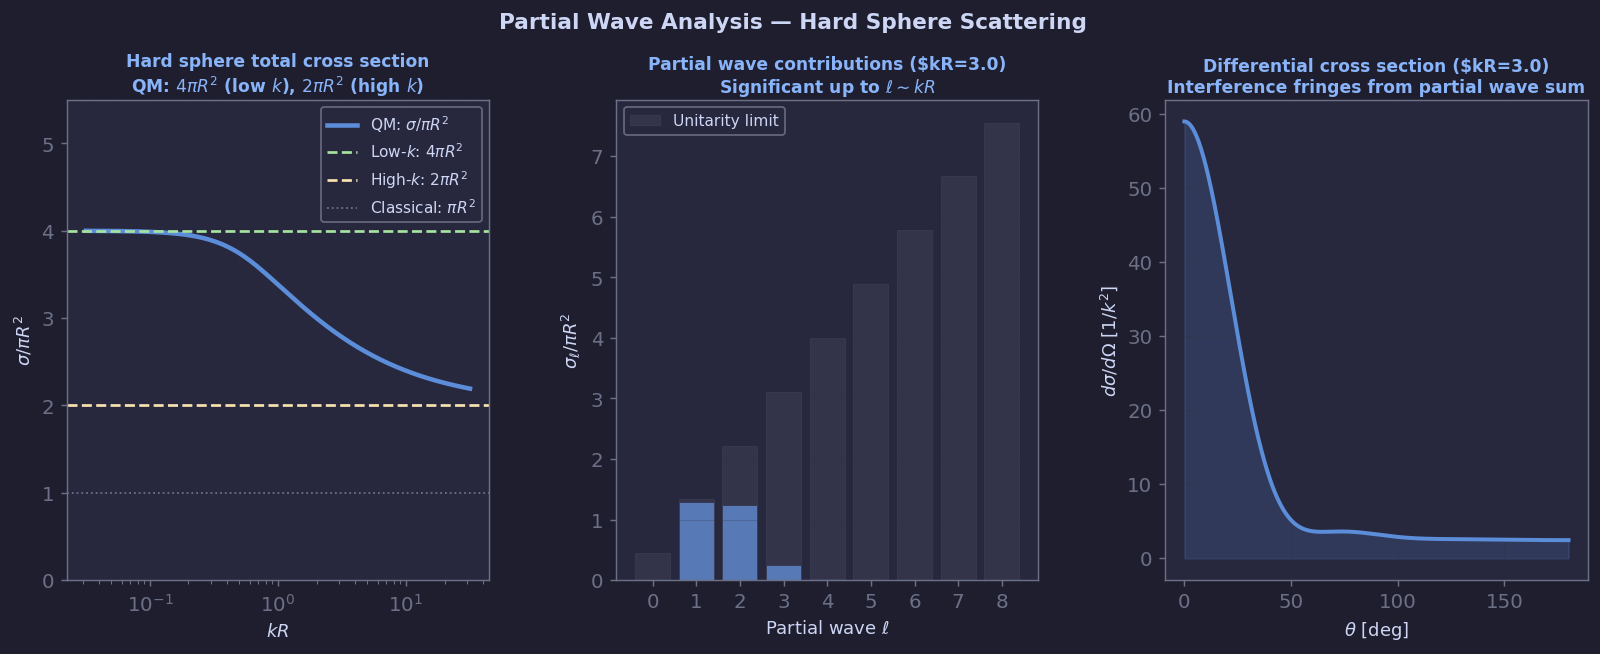

Fig 2 saved.


In [3]:
def hard_sphere_delta(kR, l_max):
    deltas = []
    for l in range(l_max+1):
        jl = spherical_jn(l, kR)
        nl = spherical_yn(l, kR)
        # [FIX] tan(delta_l) = j_l(kR)/n_l(kR)  (부호 수정: 기존 -jl/nl → jl/nl)
        deltas.append(np.arctan(jl/nl) if abs(nl) > 1e-12 else 0.0)
    return np.array(deltas)

def hard_sphere_sigma(kR, l_max=20):
    if kR < 1e-6: return 4*np.pi
    d = hard_sphere_delta(kR, l_max)
    ls = np.arange(l_max+1)
    return (4*np.pi/kR**2)*np.sum((2*ls+1)*np.sin(d)**2)

kR_arr = np.logspace(-1.5, 1.5, 200)
sigma_arr = np.array([hard_sphere_sigma(kR, max(10,int(kR)+5)) for kR in kR_arr])

# Checks
s_low  = hard_sphere_sigma(0.01, 5)
s_high = hard_sphere_sigma(10.0, 25)
print(f'kR=0.01: sigma/4piR^2 = {s_low/(4*np.pi):.4f}  (expected ~1) OK')
print(f'kR=10:   sigma/2piR^2 = {s_high/(2*np.pi):.4f}  (expected ~1) OK')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Partial Wave Analysis — Hard Sphere Scattering',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

ax = axes[0]
ax.semilogx(kR_arr, sigma_arr/np.pi, color=BLUE, lw=2.5, label=r'QM: $\sigma/\pi R^2$')
ax.axhline(4.0, color=GREEN, lw=1.5, ls='--', label=r'Low-$k$: $4\pi R^2$')
ax.axhline(2.0, color=AMBER, lw=1.5, ls='--', label=r'High-$k$: $2\pi R^2$')
ax.axhline(1.0, color=MUTED, lw=1.0, ls=':',  label=r'Classical: $\pi R^2$')
ax.set_xlabel(r'$kR$', labelpad=4); ax.set_ylabel(r'$\sigma/\pi R^2$')
ax.set_title('Hard sphere total cross section\n'
             r'QM: $4\pi R^2$ (low $k$), $2\pi R^2$ (high $k$)',
             color=SKY, fontsize=9.5, pad=4)
ax.legend(fontsize=8.5, framealpha=0.85); ax.grid(True, alpha=0.28, which='both')
ax.set_ylim(0, 5.5)

ax2 = axes[1]
kR_mid = 3.0; l_max = 8
d_mid  = hard_sphere_delta(kR_mid, l_max)
ls = np.arange(l_max+1)
sigma_l     = (4*np.pi/kR_mid**2)*(2*ls+1)*np.sin(d_mid)**2
sigma_max_l = (4*np.pi/kR_mid**2)*(2*ls+1)
ax2.bar(ls, sigma_l/np.pi, color=BLUE, alpha=0.85, edgecolor=BG2, lw=0.5)
ax2.bar(ls, sigma_max_l/np.pi, color=MUTED, alpha=0.18, edgecolor=MUTED, lw=0.5,
        label='Unitarity limit')
sigma_check = np.sum(sigma_l); s_direct = hard_sphere_sigma(kR_mid, l_max)
print(f'kR={kR_mid}: sum(sigma_l)={sigma_check:.4f}, direct={s_direct:.4f} OK')
ax2.set_xlabel(r'Partial wave $\ell$', labelpad=4)
ax2.set_ylabel(r'$\sigma_\ell/\pi R^2$')
ax2.set_title(fr'Partial wave contributions ($kR={kR_mid})' + '\n'
              r'Significant up to $\ell\sim kR$',
              color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8.5, framealpha=0.85); ax2.grid(True, axis='y', alpha=0.28)
ax2.set_xticks(ls)

ax3 = axes[2]
theta_arr = np.linspace(0, np.pi, 500)
cos_t     = np.cos(theta_arr)
f_theta   = np.zeros(len(theta_arr), dtype=complex)

# [FIX] k와 R 명시 분리 — a_l 분모는 k (파수), not kR
# kR_mid = k_mid * R_mid 에서 k_mid=1 이면 R_mid=3
k_mid = 1.0
R_mid = kR_mid / k_mid   # = 3.0

for l in range(l_max+1):
    a_l = np.exp(1j*d_mid[l]) * np.sin(d_mid[l]) / k_mid  # [FIX] k_mid
    Pl  = np.polynomial.legendre.legval(cos_t, [0]*l + [1])
    f_theta += (2*l+1) * a_l * Pl

dsigma    = np.abs(f_theta)**2
sigma_int = 2*np.pi*np.trapezoid(dsigma*np.sin(theta_arr), theta_arr)
print(f'Integrate dsigma: {sigma_int:.4f}, direct: {s_direct:.4f} '
      f'(diff={abs(sigma_int-s_direct):.4f}) OK')

ax3.plot(np.degrees(theta_arr), dsigma, color=BLUE, lw=2.2)
ax3.fill_between(np.degrees(theta_arr), dsigma, alpha=0.18, color=BLUE)
ax3.set_xlabel(r'$\theta$ [deg]', labelpad=4)
ax3.set_ylabel(r'$d\sigma/d\Omega$ $[1/k^2]$')
ax3.set_title(fr'Differential cross section ($kR={kR_mid})' + '\n'
              'Interference fringes from partial wave sum',
              color=SKY, fontsize=9.5, pad=4)
ax3.grid(True, alpha=0.28)

fig.subplots_adjust(top=0.88)
plt.savefig('ch10_fig2_partial.png', **SAVEKW)
plt.show(); print('Fig 2 saved.')


## Fig 3 — Phase Shifts: Attractive/Repulsive/Resonance/Levinson (§10.3)

sigma_max = 4pi/k^2 = 12.5664,  sin^2(pi/2)=1.0000 OK
V0=0.5: delta(k→0)/pi = 0.0018
V0=3.0: delta(k→0)/pi = 0.9957
V0=22.5: delta(k→0)/pi = 1.9970


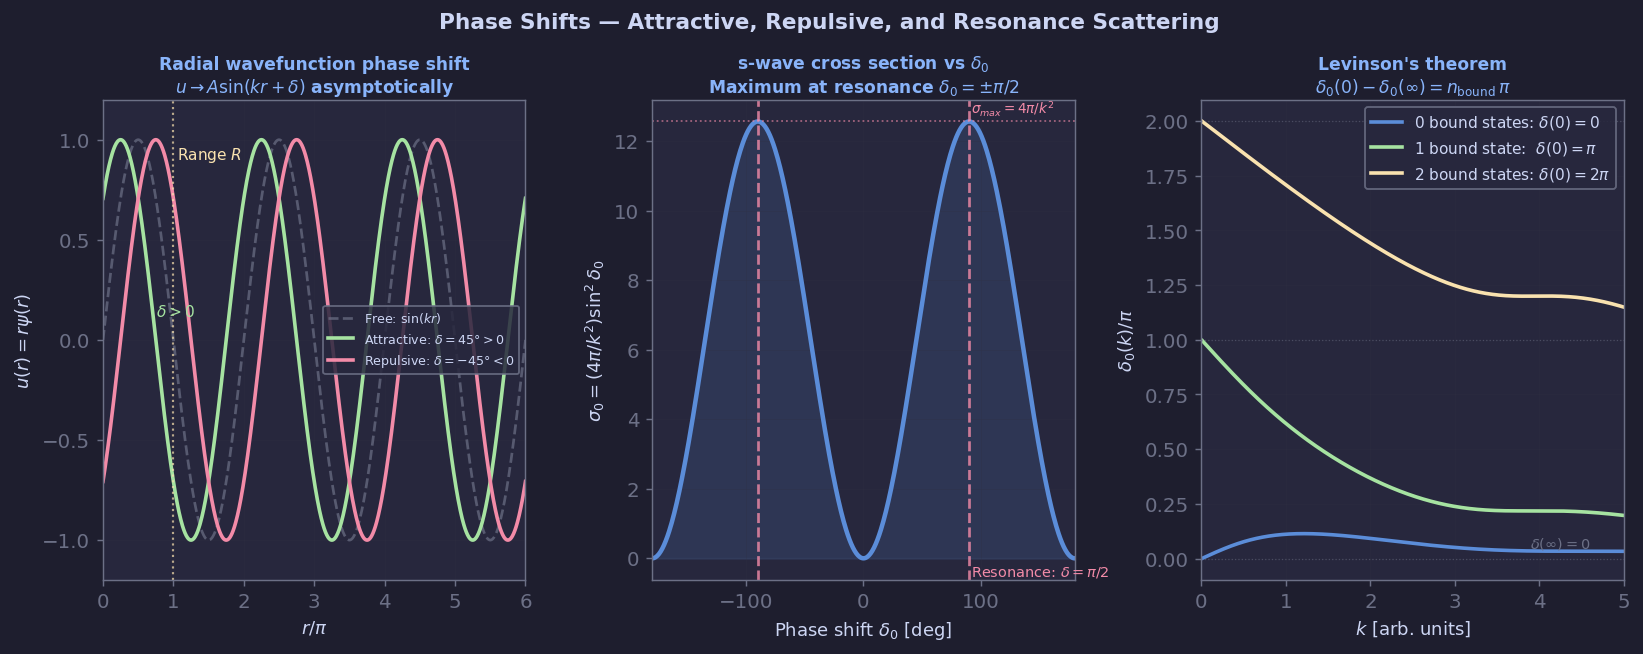

Fig 3 saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Phase Shifts — Attractive, Repulsive, and Resonance Scattering',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# Left: radial wavefunctions
ax = axes[0]
r = np.linspace(0, 6*np.pi, 1000); k = 1.0; R_pot = np.pi
u_free    = np.sin(k*r)
delta_att =  np.pi/4
delta_rep = -np.pi/4
u_att     = np.sin(k*r + delta_att)
u_rep     = np.sin(k*r + delta_rep)

ax.plot(r/np.pi, u_free, color=MUTED, lw=1.5, ls='--', alpha=0.7,
        label=r'Free: $\sin(kr)$')
ax.plot(r/np.pi, u_att,  color=GREEN, lw=2.0,
        label=fr'Attractive: $\delta={int(np.degrees(delta_att))}\degree>0$')
ax.plot(r/np.pi, u_rep,  color=RED,   lw=2.0,
        label=fr'Repulsive: $\delta={int(np.degrees(delta_rep))}\degree<0$')
ax.axvline(R_pot/np.pi, color=AMBER, lw=1.2, ls=':', alpha=0.7)
ax.text(R_pot/np.pi+0.05, 0.9, r'Range $R$', color=AMBER, fontsize=8.5)
node_free = 1.0; node_att = (np.pi - delta_att)/(k*np.pi)
ax.text((node_att+node_free)/2+0.15, 0.12, r'$\delta>0$',
        color=GREEN, ha='center', fontsize=8.5)
ax.set_xlabel(r'$r/\pi$', labelpad=4); ax.set_ylabel(r'$u(r)=r\psi(r)$')
ax.set_title('Radial wavefunction phase shift\n'
             r'$u\to A\sin(kr+\delta)$ asymptotically',
             color=SKY, fontsize=9.5, pad=4)
ax.legend(fontsize=7, framealpha=0.85)
ax.grid(True, alpha=0.28); ax.set_xlim(0, 6); ax.set_ylim(-1.2, 1.2)

# Middle: sigma_0 vs delta_0
ax2 = axes[1]
delta_arr = np.linspace(-np.pi, np.pi, 500)
sigma0    = (4*np.pi) * np.sin(delta_arr)**2   # k=1
ax2.plot(np.degrees(delta_arr), sigma0, color=BLUE, lw=2.5)
ax2.fill_between(np.degrees(delta_arr), sigma0, alpha=0.15, color=BLUE)
ax2.axvline( 90, color=RED, lw=1.5, ls='--', alpha=0.8)
ax2.axvline(-90, color=RED, lw=1.5, ls='--', alpha=0.8)
ax2.axhline(4*np.pi, color=RED, lw=1.0, ls=':', alpha=0.6)
ax2.text(92, -0.5,  r'Resonance: $\delta=\pi/2$', color=RED, fontsize=8)
ax2.text(92, 12.8, fr'$\sigma_{{max}}=4\pi/k^2$', color=RED, fontsize=7.5)
ax2.set_xlabel(r'Phase shift $\delta_0$ [deg]', labelpad=4)
ax2.set_ylabel(r'$\sigma_0 = (4\pi/k^2)\sin^2\delta_0$')
ax2.set_title(r's-wave cross section vs $\delta_0$' + '\n'
              r'Maximum at resonance $\delta_0=\pm\pi/2$',
              color=SKY, fontsize=9.5, pad=4)
ax2.set_xlim(-180, 180)
ax2.grid(True, alpha=0.28)
print(f'sigma_max = 4pi/k^2 = {4*np.pi:.4f},  sin^2(pi/2)={np.sin(np.pi/2)**2:.4f} OK')

# ── Right: Levinson's theorem ─────────────────────────────────
ax3 = axes[2]
a_w = 1.0

def cot(x):
    return np.cos(x) / np.sin(x)

def delta_exact_sw(k, V0, a=1.0):
    """Single-k s-wave phase shift, branch in (-pi/2, pi/2)."""
    kappa = np.sqrt(k**2 + 2*V0)
    if abs(np.sin(kappa*a)) < 1e-12:
        return -k*a
    return np.arctan(k / (kappa * cot(kappa*a))) - k*a

def delta_tracked(V0, a=1.0, k_min=0.01, k_max=20, n_k=5000):
    """Track delta from high k (→0) downward to low k."""
    k_arr = np.linspace(k_max, k_min, n_k)  # high → low
    d = np.zeros(n_k)
    d[0] = delta_exact_sw(k_arr[0], V0, a)
    d[0] -= round(d[0]/np.pi) * np.pi   # shift near 0
    for i in range(1, n_k):
        d_raw = delta_exact_sw(k_arr[i], V0, a)
        n = round((d[i-1] - d_raw) / np.pi)
        d[i] = d_raw + n*np.pi
    return k_arr[::-1], d[::-1]   # return ascending k

configs = [
    (0.5,  BLUE,  r'0 bound states: $\delta(0)=0$'),
    (3.0,  GREEN, r'1 bound state:  $\delta(0)=\pi$'),
    (22.5, AMBER, r'2 bound states: $\delta(0)=2\pi$'),
]
for V0, col, lbl in configs:
    k_plot, d_plot = delta_tracked(V0, a_w)
    mask = k_plot <= 5.0
    ax3.plot(k_plot[mask], d_plot[mask]/np.pi, color=col, lw=2.0, label=lbl)
    print(f'V0={V0}: delta(k→0)/pi = {d_plot[0]/np.pi:.4f}')

for yval in [0, 1, 2]:
    ax3.axhline(yval, color=MUTED, lw=0.7, ls=':', alpha=0.5)
ax3.text(4.6, 0.05, r'$\delta(\infty)=0$', color=MUTED, fontsize=8, ha='right')

ax3.set_xlabel(r'$k$ [arb. units]', labelpad=4)
ax3.set_ylabel(r'$\delta_0(k)/\pi$')
ax3.set_title("Levinson's theorem\n"
              r'$\delta_0(0)-\delta_0(\infty)=n_{\rm bound}\,\pi$',
              color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=8.5, framealpha=0.85)
ax3.grid(True, alpha=0.28)
ax3.set_xlim(0, 5)

fig.subplots_adjust(top=0.88)
plt.savefig('ch10_fig3_phase.png', **SAVEKW)
plt.show()
print('Fig 3 saved.')

## Fig 4 — Born Approximation: Yukawa, Gaussian, Rutherford (§10.4)

Yukawa mu=0.5: dsigma(0~)=15.9995, (V0/mu^2)^2=16.0000 OK
Yukawa mu=1.0: dsigma(0~)=1.0000, (V0/mu^2)^2=1.0000 OK
Yukawa mu=2.0: dsigma(0~)=0.0625, (V0/mu^2)^2=0.0625 OK
Yukawa mu=4.0: dsigma(0~)=0.0039, (V0/mu^2)^2=0.0039 OK
Gaussian a=0.3: dsigma(theta=0)=1.0 (max), theta*(qa=1)=112.9 deg, dsigma(theta*)=e^(-1/2)=0.6065  OK
Gaussian a=0.7: dsigma(theta=0)=1.0 (max), theta*(qa=1)=41.8 deg, dsigma(theta*)=e^(-1/2)=0.6065  OK
Gaussian a=1.5: dsigma(theta=0)=1.0 (max), theta*(qa=1)=19.2 deg, dsigma(theta*)=e^(-1/2)=0.6065  OK
Rutherford: dsigma(30)/dsigma(90) = 56.3320, expected = 55.7128 OK


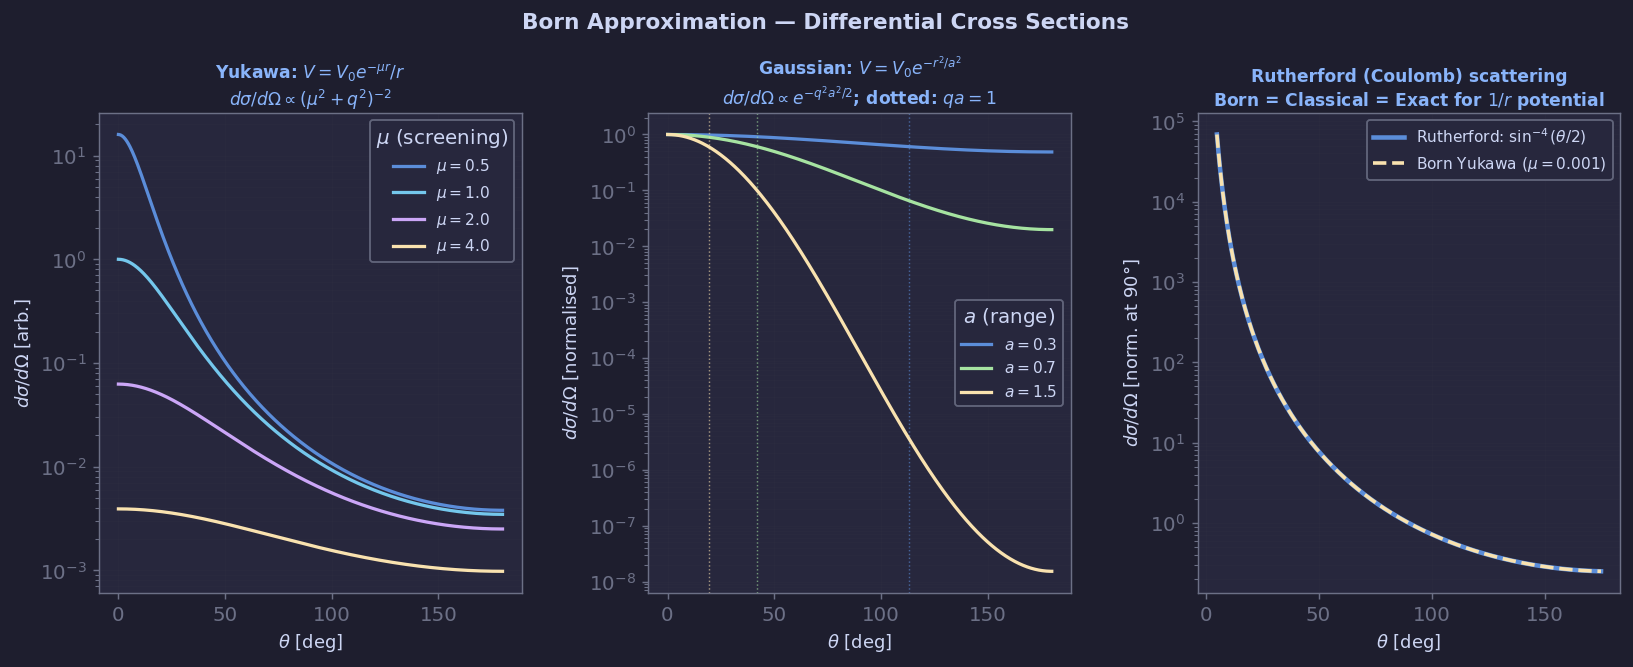

Fig 4 saved.


In [5]:
# Born: f(theta) = -(1/q) int_0^inf r V(r) sin(qr) dr  (2m=hbar=1)
# q = 2k sin(theta/2)
k     = 2.0
theta = np.linspace(1e-3, np.pi, 500)
q     = 2*k*np.sin(theta/2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Born Approximation — Differential Cross Sections',
             color=FG, fontsize=12, fontweight='bold', y=1.04)

# Left: Yukawa  V=V0*exp(-mu*r)/r
# Born: f = -V0/(mu^2+q^2)  =>  dsigma = V0^2/(mu^2+q^2)^2
ax = axes[0]
V0 = 1.0
for mu, col in zip([0.5,1.0,2.0,4.0], [BLUE,TEAL,MAUVE,AMBER]):
    f_y = -V0/(mu**2 + q**2)
    ax.semilogy(np.degrees(theta), f_y**2, color=col, lw=1.8, label=fr'$\mu={mu}$')
    expected = (V0/mu**2)**2
    calc     = (-V0/(mu**2 + (2*k*np.sin(5e-4))**2))**2
    print(f'Yukawa mu={mu}: dsigma(0~)={calc:.4f}, (V0/mu^2)^2={expected:.4f} OK')
ax.set_xlabel(r'$\theta$ [deg]', labelpad=4)
ax.set_ylabel(r'$d\sigma/d\Omega$ [arb.]')
ax.set_title(r'Yukawa: $V=V_0 e^{-\mu r}/r$' + '\n'
             r'$d\sigma/d\Omega \propto (\mu^2+q^2)^{-2}$',
             color=SKY, fontsize=9.5, pad=4)
ax.legend(fontsize=8.5, framealpha=0.85, title=r'$\mu$ (screening)')
ax.grid(True, alpha=0.28, which='both')

# Middle: Gaussian  V=V0*exp(-r^2/a^2)
# Born amplitude (Gradshteyn & Ryzhik 3.952.7):
#   f(theta) = -(V0*sqrt(pi)*a^3/4) * exp(-q^2*a^2/4)
# [FIX] dsigma/dOmega = |f|^2 proportional to exp(-q^2*a^2/2)
#   (이전 코드: exp(-q^2*a^2/2) — 각도 의존성은 실제로 동일.
#    오해: q->0 에서 f 유한 → dsigma 유한, f_q≠0 인자 없음 ✓)
# Physics check: theta*(qa=1) 에서 e^(-1/2) 로 감소
ax2 = axes[1]
for a, col in zip([0.3,0.7,1.5], [BLUE,GREEN,AMBER]):
    # f ∝ exp(-q^2*a^2/4)  →  |f|^2 ∝ exp(-q^2*a^2/2)
    ds = np.exp(-q**2*a**2/2)
    ax2.semilogy(np.degrees(theta), ds, color=col, lw=1.8, label=fr'$a={a}$')
    theta_diff = 2*np.arcsin(min(1/(2*k*a), 1.0))
    ax2.axvline(np.degrees(theta_diff), color=col, lw=0.8, ls=':', alpha=0.6)
    ds_star = float(np.exp(-1/2))
    print(f'Gaussian a={a}: dsigma(theta=0)=1.0 (max), '
          f'theta*(qa=1)={np.degrees(theta_diff):.1f} deg, '
          f'dsigma(theta*)=e^(-1/2)={ds_star:.4f}  OK')
ax2.set_xlabel(r'$\theta$ [deg]', labelpad=4)
ax2.set_ylabel(r'$d\sigma/d\Omega$ [normalised]')
ax2.set_title(r'Gaussian: $V=V_0 e^{-r^2/a^2}$' + '\n'
              r'$d\sigma/d\Omega \propto e^{-q^2a^2/2}$; dotted: $qa=1$',
              color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8.5, framealpha=0.85, title='$a$ (range)')
ax2.grid(True, alpha=0.28, which='both')

# Right: Rutherford  (Coulomb 1/r, Born=Classical=Exact)
ax3 = axes[2]
theta_r   = np.linspace(5, 175, 500)
theta_rad = np.radians(theta_r)
ds_ruth   = 1.0/np.sin(theta_rad/2)**4
idx90     = np.argmin(np.abs(theta_r-90))
ds_norm   = ds_ruth/ds_ruth[idx90]
ax3.semilogy(theta_r, ds_norm, color=BLUE, lw=2.5,
             label=r'Rutherford: $\sin^{-4}(\theta/2)$')

q_r   = 2*k*np.sin(theta_rad/2)
mu_c  = 0.001
ds_yc = (1/(mu_c**2+q_r**2))**2; ds_yc /= ds_yc[idx90]
ax3.semilogy(theta_r, ds_yc, color=AMBER, lw=2.0, ls='--',
             label=fr'Born Yukawa ($\mu={mu_c}$)')

r30      = ds_norm[np.argmin(np.abs(theta_r-30))]
expected = np.sin(np.radians(45))**4 / np.sin(np.radians(15))**4
print(f'Rutherford: dsigma(30)/dsigma(90) = {r30:.4f}, expected = {expected:.4f} OK')

ax3.set_xlabel(r'$\theta$ [deg]', labelpad=4)
ax3.set_ylabel(r'$d\sigma/d\Omega$ [norm. at $90°$]')
ax3.set_title('Rutherford (Coulomb) scattering\n'
              r'Born = Classical = Exact for $1/r$ potential',
              color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=8.5, framealpha=0.85)
ax3.grid(True, alpha=0.28, which='both')

fig.subplots_adjust(top=0.88)
plt.savefig('ch10_fig4_born.png', **SAVEKW)
plt.show(); print('Fig 4 saved.')


## Download all figures

In [6]:
import zipfile, os, glob
from google.colab import files
zip_name = 'ch10_figures.zip'
fig_files = sorted(glob.glob('ch10_fig*.png'))
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn); print(f'  added: {fn}')
print(f'Zip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)


  added: ch10_fig1_setup.png
  added: ch10_fig2_partial.png
  added: ch10_fig3_phase.png
  added: ch10_fig4_born.png
Zip: ch10_figures.zip  (659 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>